# Стохастический градиентный и координатный спуски

## Загрузка и подготовка данных (1 балл)

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [700]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\Advertising.csv', index_col=0)
df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [701]:
df.isna().sum()
# Пропусков нет

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [702]:
X, y = np.array(df.drop('sales', axis=1)), np.array(df['sales'])

## Координатный спуск (2 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [703]:
X_1 = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X_1.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [704]:
X_1 = X_1 / np.sqrt(np.sum(np.square(X_1), axis=0))

**Реализуйте алгоритм координатного спуска:**

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$ 
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [705]:
N = 100
m = X_1.shape[1]  # Количество признаков
n = X_1.shape[0]  # Количество наблюдений
y = y.ravel()
w = np.zeros(m)
for i in range(N):
    for j in range(m):  # Цикл по всем признакам
        h = X_1 @ w - X_1[:, j] * w[j]  # Считаем прогноз без j признака
        w[j] = X_1[:, j].T @ (y - h)  # Обновляем значение для j веса
        
        
print(f'Веса модели: {w}')

Веса модели: [ 41.56217205 110.13144155  73.52860638  -0.55006384]


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [706]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X_1, y)
 
print(model.coef_)

[ 41.56217205 110.13144155  73.52860638  -0.55006384]


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (7 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение**

In [707]:
means = np.mean(X, axis=0)
stds = np.std(X, axis=0)
X_new = (X - means) / stds
print(X_new[:5])

[[ 0.96985227  0.98152247  1.77894547]
 [-1.19737623  1.08280781  0.66957876]
 [-1.51615499  1.52846331  1.78354865]
 [ 0.05204968  1.21785493  1.28640506]
 [ 0.3941822  -0.84161366  1.28180188]]


**Добавим единичный столбец**

In [708]:
X_new = np.hstack([np.ones(X_new.shape[0]).reshape(-1, 1), X_new])

**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse**

In [709]:
def mse_error(y, y_pred):
    mse = np.sum((y - y_pred)**2) / y.shape[0]
    return mse
    

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза**

In [710]:
y_pred = np.mean(y)
mse = mse_error(y, y_pred)
print(mse)

27.085743750000002


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов**

In [711]:
def lin_pred(X, w):
    return X @ w

In [712]:
print(lin_pred(X_new, w)[:10])

[ 219.56484616  -11.05755963  -14.0094509   136.13404966   22.38627367
  -10.18996418  -26.06468675  -10.66857002 -240.80279274    7.04974099]


**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска.  
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [713]:
def stoch_grad_step(X, y, w, train_ind, eta):
    x_i = X[train_ind]  # Наблюдение 
    y_i = y[train_ind]
    w = w.ravel()
    y_pred = x_i @ w  # Прогноз
    error = y_pred - y_i # Ошибка
    grad = 2 * error * x_i # Считаем градиент
    w = w - eta * grad
    return w
w = np.zeros(4)
result = stoch_grad_step(X_new, y, w, 5, 0.01)
print(result)

[ 0.144      -0.23261882  0.24926889  0.29461392]


**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте основной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [714]:
def stochastic_gradient_descent(X, y, w, eta, max_iter, evklid_error):
    dist = np.inf
    list_error = list()
    count = 0
    n_samples = X.shape[0] # Количество наблюдений
    w = np.array(w)
    
    while dist > evklid_error and count < max_iter:
        w_old = w.copy() # Сохраняем старые значения
        random_index = np.random.randint(0, n_samples) # Генерируем случайный индекс
        w = stoch_grad_step(X, y, w, random_index, eta) # Делаем 1 шаг градиентного спуска и получаем веса
        y_pred = lin_pred(X, w) # Считаем метки по новым весам
        error = mse_error(y, y_pred) # Считаем ошибку
        list_error.append(error)
        dist = np.linalg.norm(w - w_old) # Считаем расстояние между векторами весов
        count += 1
        
    return w, list_error

result, err = stochastic_gradient_descent(X_new, y, np.zeros(4), 0.001, 10**7, 1e-7)
print(f'Веса стохастического градиентного спуска: {np.round(result, 3)}')
model = LinearRegression(fit_intercept=False)
model.fit(X_new, y)
print(f'Веса аналитического решения: {np.round(model.coef_, 3)}')

Веса стохастического градиентного спуска: [14.03   3.961  2.902 -0.262]
Веса аналитического решения: [14.023  3.919  2.792 -0.023]


In [715]:
# Так как веса достаточно сильно прыгают от запуска к запуску, 
# то можно попробывать усредить сразу несколько вариантов весов и получить примерную среднюю оценку
result_list = list()
for i in range(10):
    result, err = stochastic_gradient_descent(X_new, y, np.zeros(4), 0.001, 10**5, 1e-7)
    result_list.append(result)
print(f'Средние веса: {np.round(np.mean(np.array(result_list), axis=0), 3)}')
    

Средние веса: [ 1.4006e+01  3.9550e+00  2.7900e+00 -1.2000e-02]


 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

**Постройте график зависимости ошибки от номера итерации**

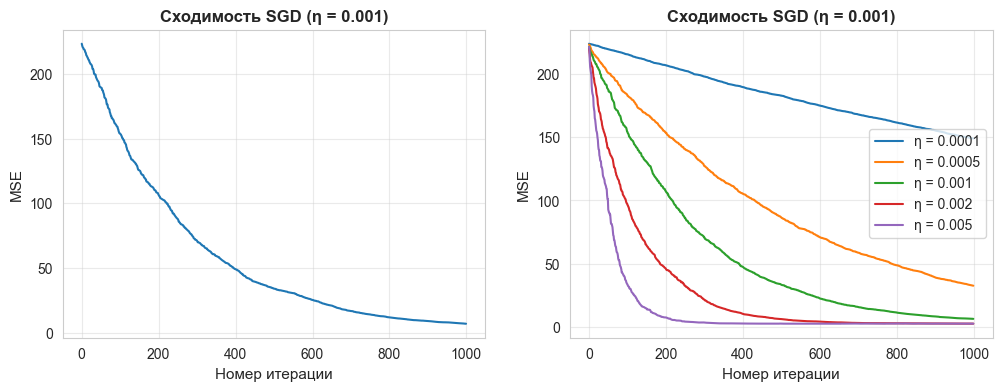

In [716]:
result, err = stochastic_gradient_descent(X_new, y, np.zeros(4), 0.001, 10**5, 1e-7)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1 График
sns.lineplot(err[:1000], ax=axes[0])
axes[0].set_xlabel('Номер итерации', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].set_title('Сходимость SGD (η = 0.001)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.4)

# 2 График
list_error = []
etas = [0.0001, 0.0005, 0.001, 0.002, 0.005]
labels = [f'η = {eta}' for eta in etas]
for j, i in enumerate([0.0001,  0.0005, 0.001, 0.002, 0.005]):
    result, err1 = stochastic_gradient_descent(X_new, y, np.zeros(4), i, 10**5, 1e-7)
    sns.lineplot(err1[:1000], ax=axes[1], label = labels[j])
axes[1].set_xlabel('Номер итерации', fontsize=11)
axes[1].set_ylabel('MSE', fontsize=11)
axes[1].set_title('Сходимость SGD (η = 0.001)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.4)

**Выведите вектор весов, к которому сошелся метод.**

In [717]:
result, err = stochastic_gradient_descent(X_new, y, np.zeros(4), 0.001, 10**5, 1e-7)
print(f'Веса стохастического градиентного спуска: {np.round(result, 3)}')

Веса стохастического градиентного спуска: [14.114  3.898  2.809 -0.091]


**Выведите среднеквадратичную ошибку на последней итерации.**

In [718]:
print(f'MSE на последней итерации: {np.round(err[-1], 4)}')

MSE на последней итерации: 2.7971
